# X-Ray Security Scanner using YOLOv11

## Object Detection

Object Detection goes beyond simple image classification. While classification answers *what* is in an image, object detection answers what is in the image and where it is located by drawing precise bounding boxes around target items.

Benefits of modern object detection architectures:

* Real-time inference speeds (essential for security workflows)
* Handles multiple overlapping targets simultaneously
* Pinpoints exact location coordinates of anomalous items

---

## YOLO (You Only Look Once)

YOLO is a revolutionary family of real-time object detection models. Introduced by Joseph Redmon et al. in 2015, it completely shifted computer vision away from slow, multi-stage pipeline approaches like R-CNN.

**Historical Background**

Before YOLO:

* Detectors used a sliding-window or region-proposal approach.
* Networks had to run hundreds of separate times on a single image, making real-time processing impossible.

YOLO showed that:

> A single neural network predicts bounding boxes and class probabilities directly from full images in one evaluation pass.

Its core design philosophy is:

* Blazing fast speed
* Global contextual understanding (sees the entire image at once)
* Unified end-to-end optimization

**Evolution of YOLO**

The framework has evolved rapidly through community and industry updates:

| Era | Main Architectures | Major Breakthrough |
| --- | --- | --- |
| **Legacy** | YOLOv1 – YOLOv4 | Introduction of single-pass grid regression. |
| **Modern** | YOLOv5 – YOLOv8 | Anchor-free detection heads and native PyTorch integration. |
| **Current (2026)** | **YOLOv11** | Enhanced feature extraction backbones and optimized multi-scale processing kernels. |

The version we are using is: **YOLOv11 (Nano Variant: `yolo11n.pt`)**

---

### Why YOLOv11 is Revolutionary

YOLOv11 introduces critical architectural advancements over past iterations:

| Innovation | Importance |
| --- | --- |
| **Anchor-Free Head** | Directly predicts bounding box centers instead of guessing offset ratios from preset boxes. |
| **Optimized C3k2 Blocks** | Deeper feature extraction with significantly reduced computational floating-point operations. |
| **Agnostic NMS** | Advanced overlapping suppression ensures clean item separation in tightly packed bags. |

---

## **OPIXray Dataset Adaptation**

**Important:** The raw OPIXray dataset coordinates are formatted as raw corner pixel allocations, while YOLOv11 demands normalized midpoints.

| Property | Raw OPIXray Format | YOLOv11 Target Format |
| --- | --- | --- |
| **Coordinate System** | Bounding Box Corners ($x_{\text{min}}, y_{\text{min}}, x_{\text{max}}, y_{\text{max}}$) | Normalized Center Point ($x_{\text{center}}, y_{\text{center}}, w, h$) |
| **Value Boundaries** | Raw Pixels (e.g., $0$ to $1024$) | Ratio Floating Points ($0.0$ to $1.0$) |
| **File Mapping** | CSV or Global Spreadsheet | One isolated `.txt` file per image |

**The Mathematical Transformation Matrix:**
To make the data compliant, raw annotations must undergo the following translation conversion:

$$x_{\text{center}} = \frac{x_{\text{min}} + x_{\text{max}}}{2 \times \text{Image Width}}$$

$$y_{\text{center}} = \frac{y_{\text{min}} + y_{\text{max}}}{2 \times \text{Image Height}}$$

$$\text{width} = \frac{x_{\text{max}} - x_{\text{min}}}{\text{Image Width}}$$

$$\text{height} = \frac{y_{\text{max}} - y_{\text{min}}}{\text{Image Height}}$$

---

### Target Classes for Security Screening

Our configuration file (`data.yaml`) maps the network's final Softmax layers to detect 5 distinct security threat categories:

| Class ID | Target Object |
| --- | --- |
| **0** | Knife |
| **1** | Gun |
| **2** | Wrench |
| **3** | Plier |
| **4** | Scissors |

---

## YOLOv11 Network Architecture

YOLOv11 splits its deep learning tasks into three essential physical sections inside the tensor pipeline:

```
[ Input Image (640x640) ] ──> [ Backbone (Feature Extraction) ] ──> [ Neck (Feature Pyramids) ] ──> [ Head (Predictions) ]

```

* **The Backbone:** A modified convolutional network that downsamples the X-ray frames to discover abstract structural patterns (metal profiles, sharp contours).
* **The Neck:** Uses Feature Pyramid Networks (FPN) to mix low-level spatial details with deep semantic indicators. This helps the network catch huge weapons and tiny razor blades equally well.
* **The Head:** Spits out the final bounding box locations, object validation scores, and target class probabilities.

## Install Dependencies

In [1]:
%pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


## Download Dataset from Roboflow

In [7]:
from roboflow import Roboflow

rf = Roboflow(api_key="OYIEly6ImErPA1ayBoVd")
project = rf.workspace("deeplearning-xray-model-training").project("prohibited-items-x-rayyolov8")
dataset = project.version(2346).download("yolov11")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Prohibited-Items-X-rayYolov8-2346 in yolov11:: 100%|██████████| 22296/22296 [00:06<00:00, 3465.84it/s]


Dataset downloaded to: /content/Prohibited-Items-X-rayYolov8-2346


## Visualize Sample Images

Showing image: P00454_jpg.rf.af49a254b2a3abcea99486f9e7b1e1c0.jpg


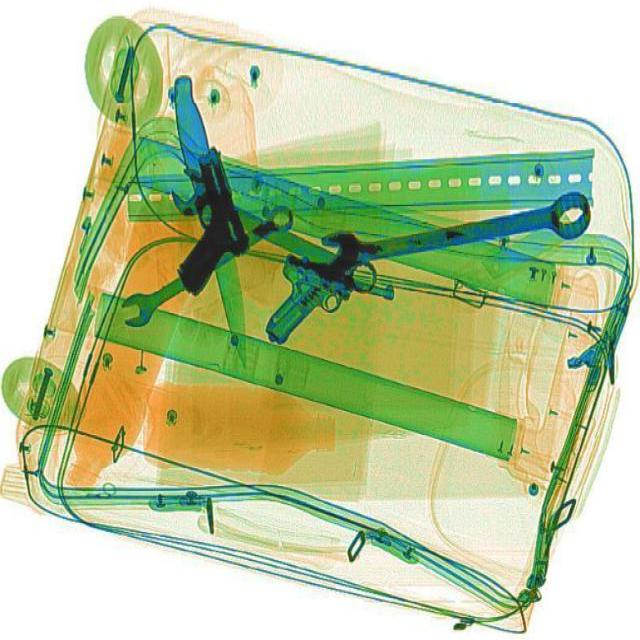

In [47]:
import glob
import os
import random
from PIL import Image
from IPython.display import Image as IPImage, display


# 1. Locate the first image path using glob
idx = random.randint(0,100)
search_pattern = os.path.join(dataset.location, 'train', 'images', '*.jpg')
image_paths = glob.glob(search_pattern)
first_image_path = image_paths[idx]

# 2. Display the image cleanly in your notebook
print(f"Showing image: {os.path.basename(first_image_path)}")
display(IPImage(filename=first_image_path, width=500))

## Check the data.yaml

In [56]:
# Construct the explicit path to the configuration file
yaml_path = os.path.join(dataset.location, "data.yaml")

print(f"Target configuration path locked: {yaml_path}")

# Peek inside to check the target classes (e.g., Guns, Knives, Scissor targets)
with open(yaml_path, 'r') as f:
    print("\n--- data.yaml Contents ---")
    print(f.read())

Target configuration path locked: /content/Prohibited-Items-X-rayYolov8-2346/data.yaml

--- data.yaml Contents ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['-', '- collaborate with your team on computer vision projects', 'Roboflow is an end-to-end computer vision platform that helps you', 'Sixray - v4 Yolo_data_640', 'This dataset was exported via roboflow.com on February 11- 2023 at 6-09 AM GMT']

roboflow:
  workspace: deeplearning-xray-model-training
  project: prohibited-items-x-rayyolov8
  version: 2346
  license: CC BY 4.0
  url: https://universe.roboflow.com/deeplearning-xray-model-training/prohibited-items-x-rayyolov8/dataset/2346


## Prepare YOLOv11 Model

In [36]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')

print(model.info())

YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.7 GFLOPs
(181, 9458752, 0, 21.718374400000002)


## Train the model

In [37]:
# Start the optimization backward-pass
results = model.train(
    data=yaml_path,      # Point directly to Roboflow's autogenerated file
    epochs=2,            # Execute 15 standard training epochs
    imgsz=640,           # Target standard pixel square resolution bounds
    batch=16,            # Parallel batch streams
    device=0,            # Force onto the Tesla T4 cloud GPU
    workers=2            # Multi-threading loaders
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Prohibited-Items-X-rayYolov8-2346/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

##  Plot Training Results

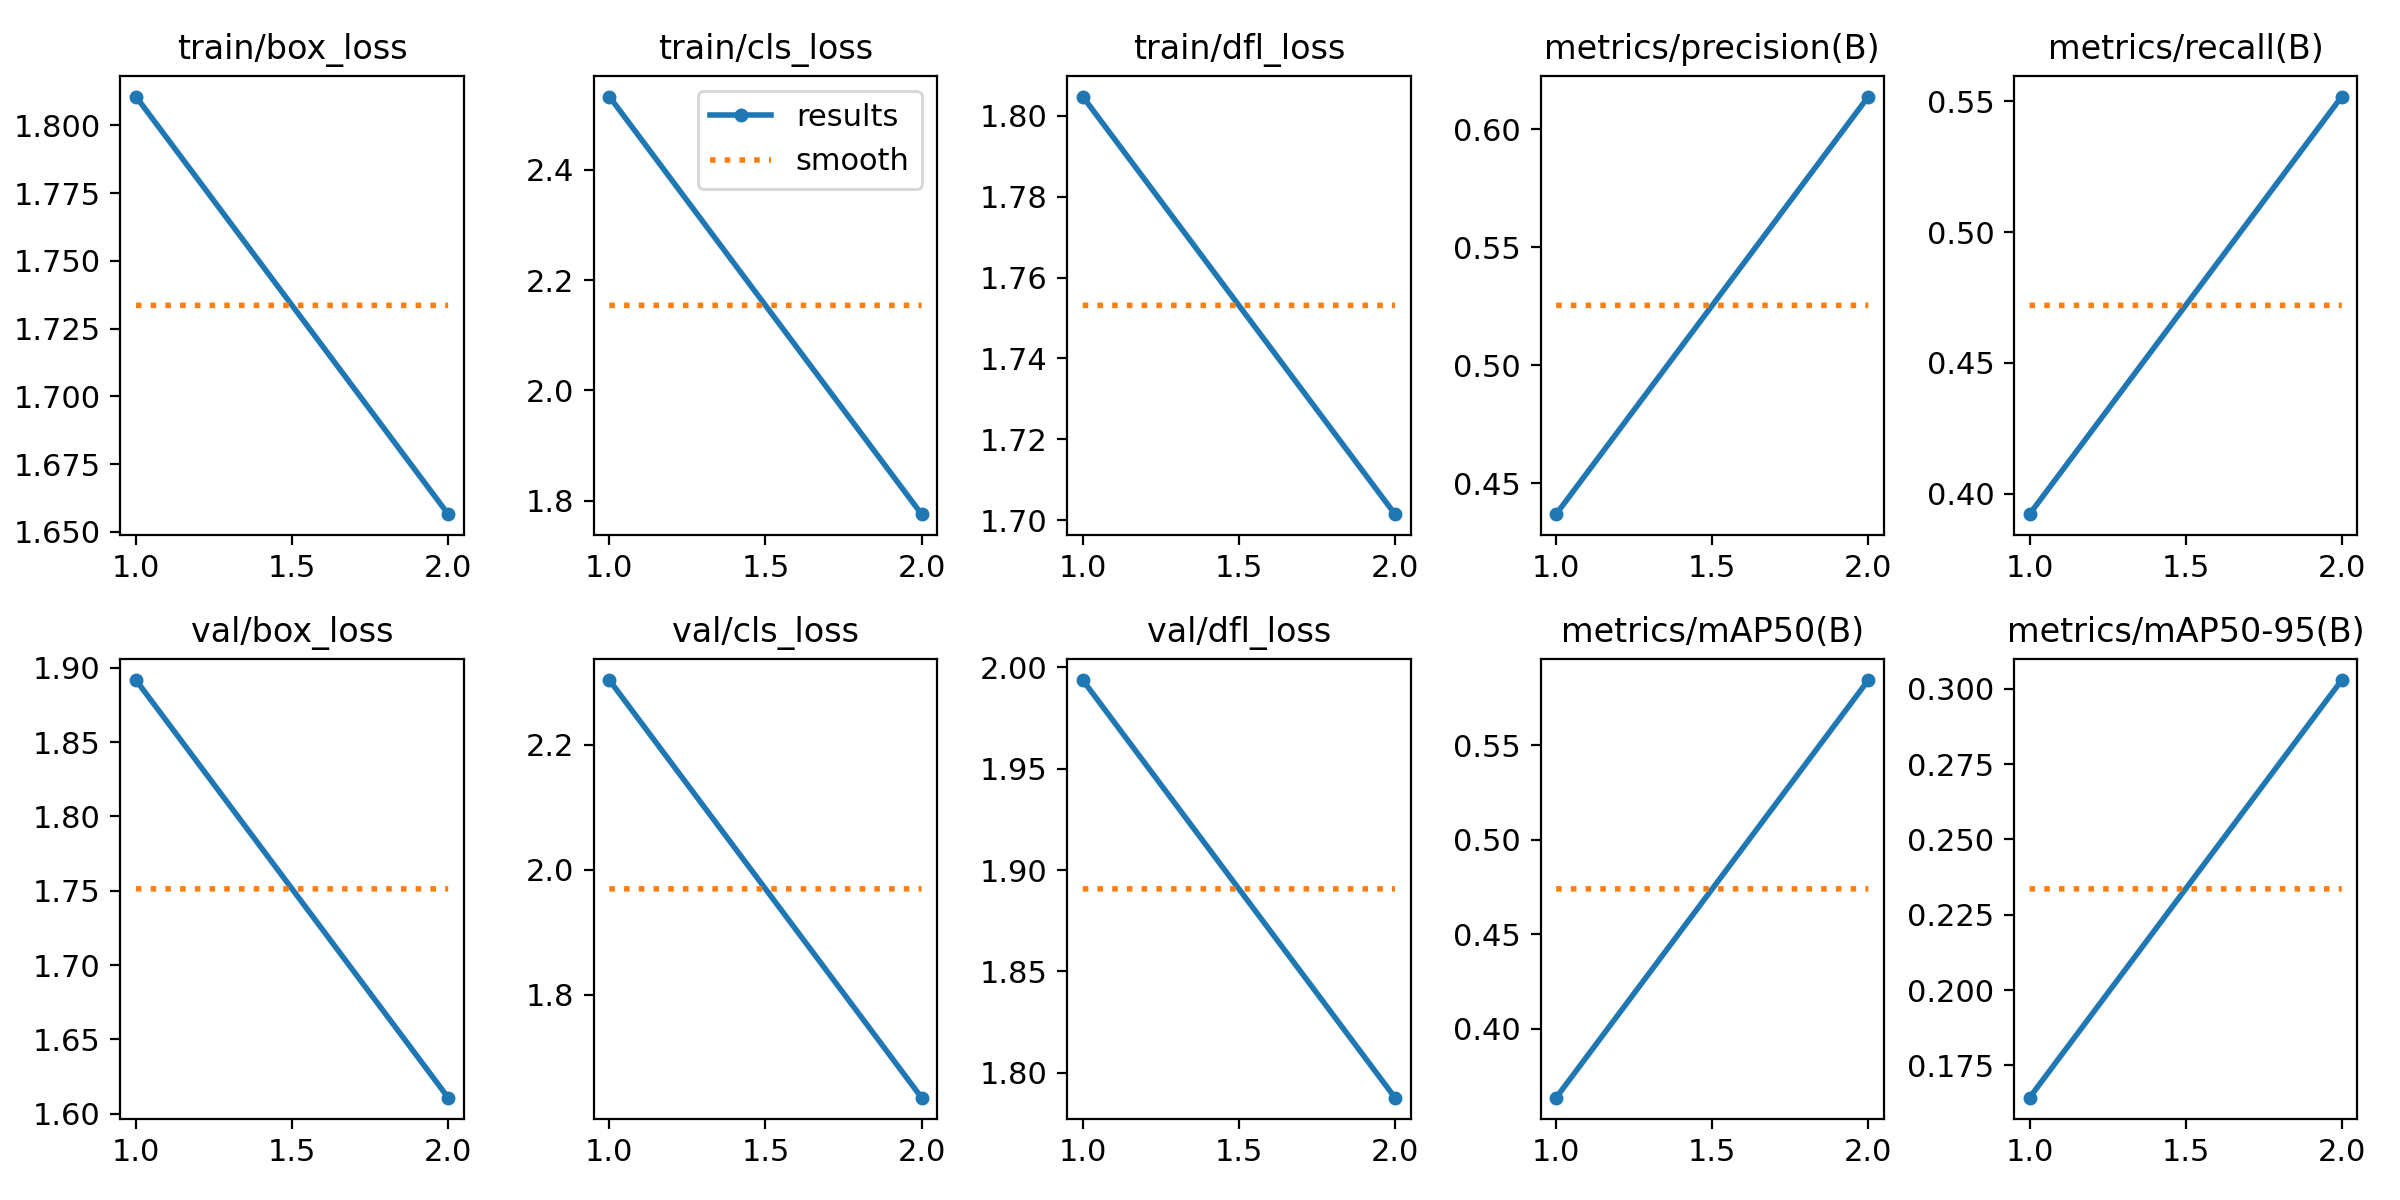

In [51]:
results_img = '/content/runs/detect/train-3/results.png'
display(IPImage(results_img, width=900))

## Confusion Matrix

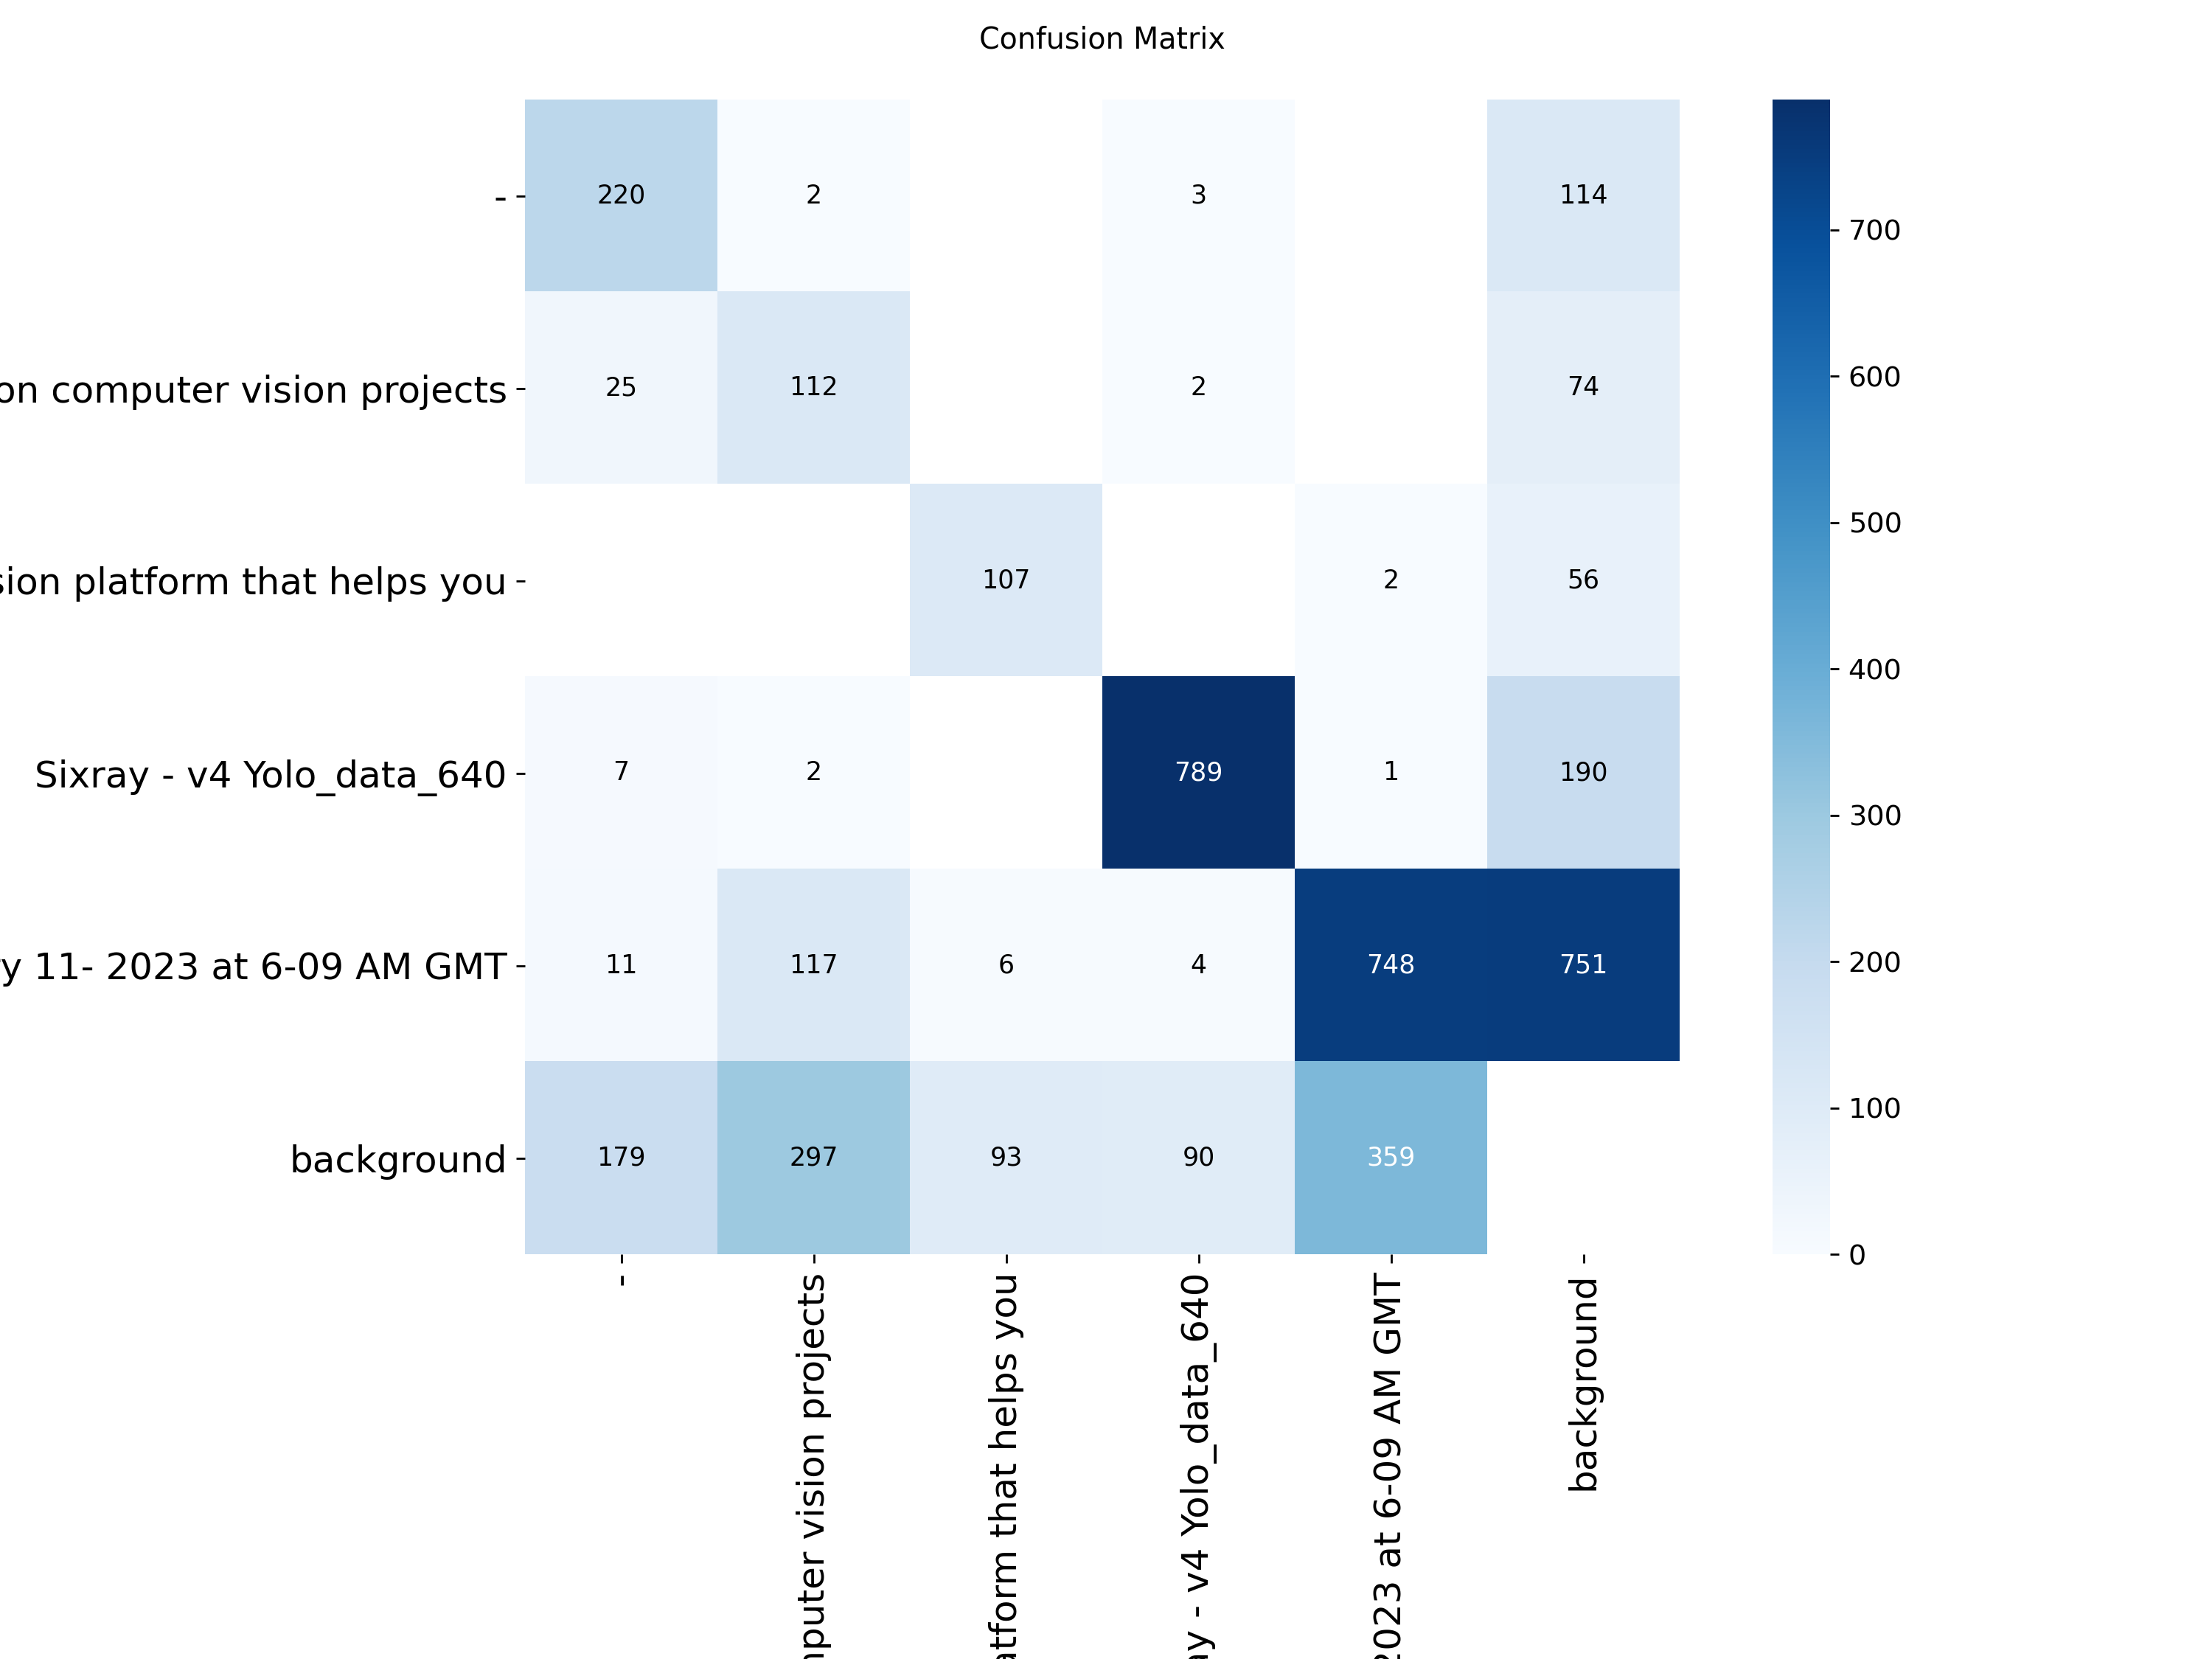

In [53]:
display(IPImage('/content/runs/detect/train-3/confusion_matrix.png', width=700))

##

## Evaluate

In [57]:
# Load best weights and validate on test set
best_model = YOLO('/content/runs/detect/train-3/weights/best.pt')

metrics = best_model.val(
    data=yaml_path,
    split='test'  # evaluate on test split
)

print(f"\nFINAL RESULTS:")
print(f"   mAP@50:    {metrics.box.map50:.4f}")
print(f"   mAP@50-95: {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1546.1±506.2 MB/s, size: 46.5 KB)
val: Scanning /content/Prohibited-Items-X-rayYolov8-2346/test/labels.cache... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 278.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 3.6it/s 13.9s
                   all        797       1495      0.658      0.494      0.563      0.293
                     -         79        121      0.786      0.281      0.411      0.181
- collaborate with your team on computer vision projects        212        302      0.607      0.185      0.333      0.171
Roboflow is an end-to-end computer vision platform that helps you         97        120      0.622      0.467       0.55      0.257
Sixray - v4 Yolo_data_640     